# SFISTA sparse recovery training loss comparison (PyTorch)

Not MMV: infer one sparse vector `x` directly from `y` and `A`. No measurement-column vectorization.

Goal: compare training losses:

1. supervised MSE: `||x_hat - x_true||_2^2`
2. supervised NNMSE: `||x_hat - x_true||_2^2 / (||x_true||_2^2 + eps)`
3. unsupervised LASSO objective: `0.5 * ||A x_hat - y||_2^2 + lam * ||x_hat||_1`
4. unsupervised cross-validation: solve on a random per-sample measurement split, train with `||A_val x_hat - y_val||_2^2`, learn `lam`

For LASSO training only, normalize each sample so that `||A.T @ y||_inf = 1`, and use fixed `lam` values `0.2` and `0.8`. The same scale is applied to `x_true` for test metrics.

For cross-validation training, each batch sample gets an independent random train/validation row split of `A` and `y`. Test metrics use the full measurement set.

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"

import sys
from pathlib import Path
from time import time

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "src"))
from fa2026.optim import SFISTA

In [ ]:
np.random.seed(2)
torch.manual_seed(2)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# objective
lasso_lams = {
    "lasso_0.2": 0.2,
    "lasso_0.8": 0.8,
}
cv_loss_name = "cv_lam"
cv_train_ratio = 0.8

N_iter = 6
lam_init = 0.2 # choose a high value for CV (otherwise we are in a flat area)
lr = 1e-3
batch_size = 128
test_size = 1024
N = 30  # dim(x)
M = 15  # dim(y)


## Data

`x`: `(batch, N)`, `y`: `(batch, M)`, `A`: `(M, N)`.

In [3]:

p = 0.1
noise_std = 1.0

A = torch.randn(M, N, device=device)


def make_batch(size=batch_size):
    support = (torch.rand(size, N, device=device) < p).float()
    x = torch.randn(size, N, device=device) * support
    y = x @ A.T + noise_std * torch.randn(size, M, device=device)
    return y, x


y, x = make_batch()
print("x", tuple(x.shape), "y", tuple(y.shape), "A", tuple(A.shape))


x (128, 30) y (128, 15) A (15, 30)


## Model

In [4]:

L = torch.linalg.norm(A, ord=2) ** 2
gamma_init = float((1.0 / L).detach().cpu())


def make_model(trainable_lam=True, lam_value=lam_init):
    model = SFISTA(
        n_iterations=N_iter,
        gamma_init=gamma_init,
        norm_A=False,
        positive=False,
    ).to(device)
    lam_tensor = torch.tensor(float(lam_value), device=device)
    if trainable_lam:
        model.lam = torch.nn.Parameter(torch.log(torch.expm1(lam_tensor)))
    else:
        model.register_buffer("lam", lam_tensor)
    return model


print("gamma_init", gamma_init)
print("trainable params (supervised)", sum(p.numel() for p in make_model().parameters()))
print("trainable params (fixed-lam LASSO)", sum(p.numel() for p in make_model(trainable_lam=False).parameters()))

gamma_init 0.015081537887454033
trainable params (supervised) 7
trainable params (fixed-lam LASSO) 6


## Losses

In [5]:
def current_lam(model):
    if getattr(model.lam, "requires_grad", False):
        return F.softplus(model.lam)
    return model.lam


def forward_sfista(model, y, train_iter, A_batch=None, lam=None):
    if A_batch is None:
        A_batch = A
    if lam is None:
        lam = current_lam(model)
    return model(y, t=train_iter, A=A_batch, lam=lam)


def mse_loss(x_hat, x_true):
    return ((x_hat - x_true) ** 2).sum(dim=1).mean()


def nnmse_loss(x_hat, x_true, eps=1e-12):
    err = ((x_hat - x_true) ** 2).sum()
    denom = (x_true ** 2).sum().clamp_min(eps)
    return err / denom


def normalize_lasso_batch(y, x, eps=1e-12):
    scale = (y @ A).abs().amax(dim=1, keepdim=True).clamp_min(eps)
    return y / scale, x / scale, scale


def lasso_objective(x_hat, y, lam):
    residual = x_hat @ A.T - y
    data_fit = 0.5 * (residual ** 2).sum(dim=1)
    sparsity = torch.abs(x_hat).sum(dim=1)
    return (data_fit + lam * sparsity).mean()


def make_cv_split(y, train_ratio=cv_train_ratio):
    n_train = int(round(train_ratio * M))
    n_train = min(max(n_train, 1), M - 1)
    indices = torch.stack([torch.randperm(M, device=y.device) for _ in range(y.shape[0])])
    train_idx = indices[:, :n_train]
    val_idx = indices[:, n_train:]
    return (
        y.gather(1, train_idx),
        A[train_idx],
        y.gather(1, val_idx),
        A[val_idx],
    )

def cv_objective(x_hat, y_val, A_val):
    residual = torch.bmm(A_val, x_hat.unsqueeze(-1)).squeeze(-1) - y_val
    return (residual ** 2).sum(dim=1).mean()

supervised_loss_fns = {
    "mse": mse_loss,
    "nnmse": nnmse_loss,
}

def to_db(value):
    return 10 * np.log10(max(float(value), 1e-12))

## Train / evaluate

In [ ]:
def evaluate(model, y, x, train_iter=N_iter, lam=None):
    model.eval()
    with torch.no_grad():
        if lam is None:
            lam = current_lam(model)
        x_hat = forward_sfista(model, y, train_iter, lam=lam)
        metrics = {
            "mse": float(mse_loss(x_hat, x).cpu()),
            "nnmse": float(nnmse_loss(x_hat, x).cpu()),
        }
        metrics["lasso"] = float(lasso_objective(x_hat, y, lam).cpu())
        return metrics


def train(loss_name, max_steps=500, cv_ratio=cv_train_ratio):
    is_lasso = loss_name in lasso_lams
    is_cv = loss_name == cv_loss_name
    fixed_lam = lasso_lams.get(loss_name, lam_init)

    model = make_model(trainable_lam=not is_lasso, lam_value=fixed_lam)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    y_test, x_test = make_batch(test_size)
    if is_lasso:
        y_test, x_test, _ = normalize_lasso_batch(y_test, x_test)

    history = {
        "train_loss": [],
        "test_mse": [],
        "test_nnmse": [],
        "test_lasso": [],
        "lam": [],
    }

    t0 = time()
    for train_iter in range(1, N_iter + 1):
        for step in range(max_steps):
            model.train()
            y_train, x_train = make_batch()
            if is_lasso:
                y_train, x_train, _ = normalize_lasso_batch(y_train, x_train)

            if is_cv:
                y_inner, A_inner, y_val, A_val = make_cv_split(y_train, cv_ratio)
                x_hat = forward_sfista(model, y_inner, train_iter, A_batch=A_inner)
                loss = cv_objective(x_hat, y_val, A_val)
            else:
                x_hat = forward_sfista(model, y_train, train_iter)
                if is_lasso:
                    loss = lasso_objective(x_hat, y_train, current_lam(model))
                else:
                    loss = supervised_loss_fns[loss_name](x_hat, x_train)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            lam_now = current_lam(model).detach()
            metrics = evaluate(model, y_test, x_test, train_iter, lam=lam_now)
            history["train_loss"].append(float(loss.detach().cpu()))
            history["test_mse"].append(metrics["mse"])
            history["test_nnmse"].append(metrics["nnmse"])
            history["test_lasso"].append(metrics["lasso"])
            history["lam"].append(float(lam_now.cpu()))

        msg = (
            f"{loss_name} | iter {train_iter:02d} | "
            f"train {to_db(history['train_loss'][-1]):.2f} dB | "
            f"test NNMSE {to_db(history['test_nnmse'][-1]):.2f} dB"
        )
        if is_lasso or is_cv:
            msg += f" | test LASSO {to_db(history['test_lasso'][-1]):.2f} dB"
        if is_cv:
            msg += f" | lam {history['lam'][-1]:.4g}"
        print(msg)

    final_lam = current_lam(model).detach()
    return {
        "model": model,
        "history": history,
        "seconds": time() - t0,
        "final_lam": float(final_lam.cpu()),
        "final": evaluate(model, y_test, x_test, lam=final_lam),
    }

In [7]:
results = {name: train(name) for name in [cv_loss_name, "lasso_0.2", "lasso_0.8", "mse", "nnmse"]}

for name, result in results.items():
    final = result["final"]
    msg = (
        f"{name}: "
        f"MSE={final['mse']:.4e} ({to_db(final['mse']):.2f} dB), "
        f"NNMSE={final['nnmse']:.4e} ({to_db(final['nnmse']):.2f} dB)"
    )
    if name in lasso_lams or name == cv_loss_name:
        msg += f", LASSO={final['lasso']:.4e} ({to_db(final['lasso']):.2f} dB)"
    if name == cv_loss_name:
        msg += f", lam={result['final_lam']:.4g}"
    msg += f", time={result['seconds']:.2f}s"
    print(msg)

cv_lam | iter 01 | train -15.58 dB | test NNMSE -0.78 dB | test LASSO 11.98 dB | lam 0.4805
cv_lam | iter 02 | train -15.96 dB | test NNMSE 9.76 dB | test LASSO 29.14 dB | lam 0.4593
cv_lam | iter 03 | train -14.86 dB | test NNMSE 11.59 dB | test LASSO 30.97 dB | lam 0.4444
cv_lam | iter 04 | train -15.58 dB | test NNMSE 6.68 dB | test LASSO 25.28 dB | lam 0.4317
cv_lam | iter 05 | train -15.74 dB | test NNMSE 4.93 dB | test LASSO 22.86 dB | lam 0.4199
cv_lam | iter 06 | train -16.44 dB | test NNMSE -0.14 dB | test LASSO 11.38 dB | lam 0.4159
lasso_0.2 | iter 01 | train -13.30 dB | test NNMSE -1.19 dB | test LASSO -13.34 dB
lasso_0.2 | iter 02 | train -14.19 dB | test NNMSE -1.49 dB | test LASSO -13.90 dB
lasso_0.2 | iter 03 | train -14.29 dB | test NNMSE -1.60 dB | test LASSO -14.09 dB
lasso_0.2 | iter 04 | train -14.51 dB | test NNMSE -1.68 dB | test LASSO -14.17 dB
lasso_0.2 | iter 05 | train -14.45 dB | test NNMSE -1.72 dB | test LASSO -14.21 dB
lasso_0.2 | iter 06 | train -14.11 d

## Curves

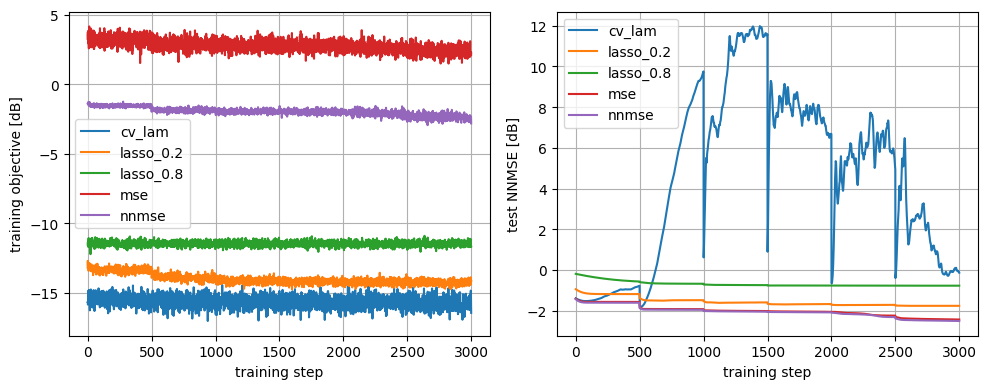

In [8]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
for name, result in results.items():
    plt.plot([to_db(v) for v in result["history"]["train_loss"]], label=name)
plt.xlabel("training step")
plt.ylabel("training objective [dB]")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
for name, result in results.items():
    plt.plot([to_db(v) for v in result["history"]["test_nnmse"]], label=name)
plt.xlabel("training step")
plt.ylabel("test NNMSE [dB]")
plt.grid(True)
plt.legend()

plt.tight_layout()
